In [1]:
from aggregation.subject_utils import get_subject_image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
extracted_data = pd.read_csv('PointTool/point_extractor_by_frame_extractions.csv')

Let's see what the extracted data looks like:

In [3]:
extracted_data

,classification_id,user_name,user_id,workflow_id,task,created_at,subject_id,extractor,data.aggregation_version,data.frame0.T0_tool0_x,data.frame0.T0_tool0_y
0,708110341,ramanakumars,2245813,30201,T0,2026-02-23 18:26:14 UTC,117477842,point_extractor_by_frame,5.3.0,[204.25],[221.4666748046875]
1,708110370,ramanakumars,2245813,30201,T0,2026-02-23 18:26:21 UTC,117477807,point_extractor_by_frame,5.3.0,[266.25],[259.4666748046875]
2,708110480,ramanakumars,2245813,30201,T0,2026-02-23 18:26:45 UTC,117466568,point_extractor_by_frame,5.3.0,"[431.25, 717.25, 840.25]","[338.4666748046875, 328.4666748046875, 242.466..."


Each row has a classification id, user info, subject information and the relevant data for that tool. In the case of points, the data are the X and Y coordinates. The naming convection is data.\[frame number\].\[task\]\_\[tool number\]\_\[coordinate\]. For this project, there is only frame per image (i.e. a single image subject) and there is only one task and tool for this task (T0, tool0). 

Note that these are currently formatted as JSON strings, so when plotting, we need to extract them into lists.

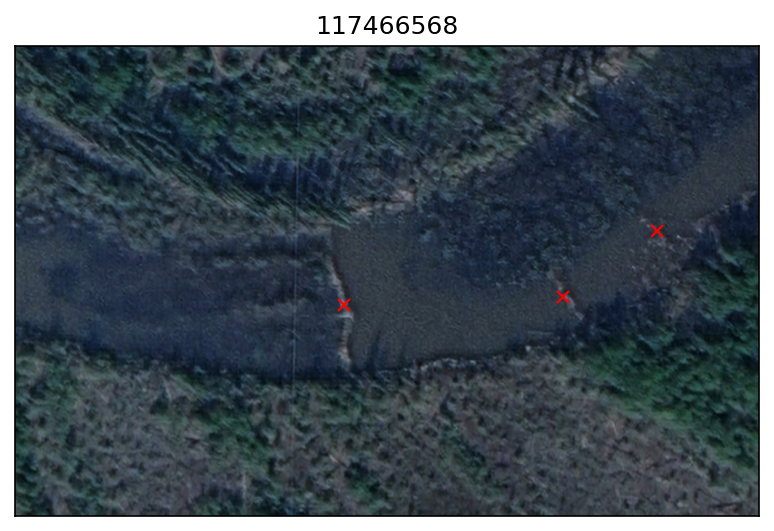

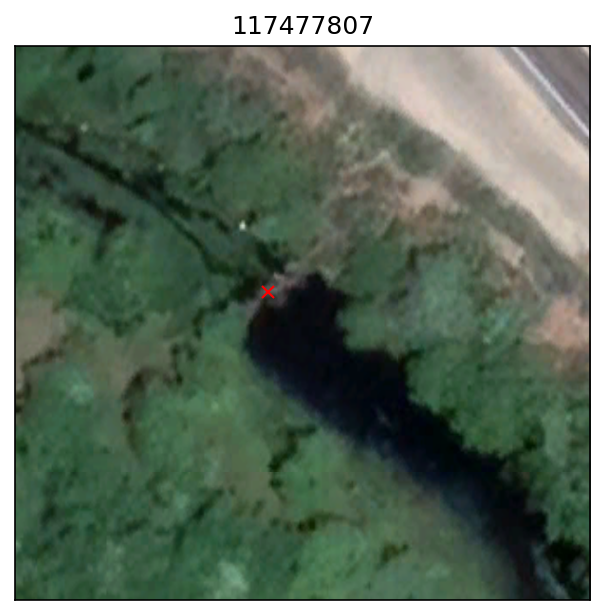

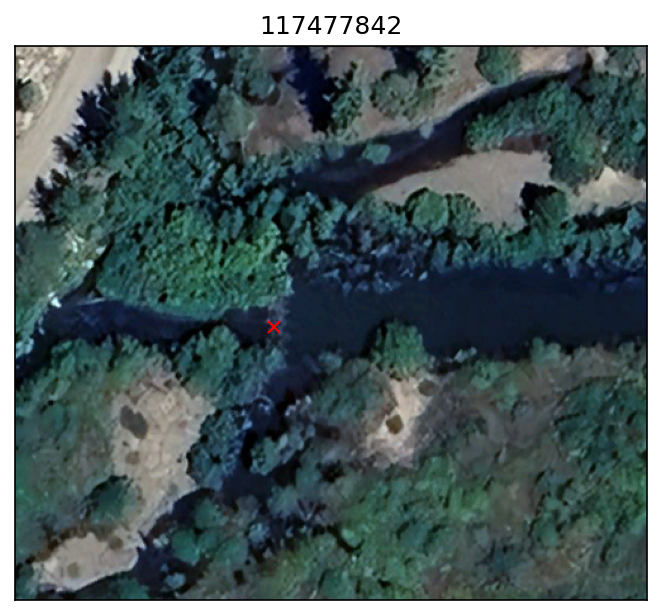

In [4]:
# so that we can plot all classifications for one subject
subject_ids = np.unique(extracted_data['subject_id'])

for subject_id in subject_ids:

    # get the classifications for this subject
    classifications = extracted_data[extracted_data['subject_id'] == subject_id]

    # get the corresponding image (see aggregation/subject_utils.py for the relevant code)
    image = get_subject_image(subject_id)

    fig, ax = plt.subplots(1, 1, dpi=150)
    ax.imshow(image)
    
    for idx, classification in classifications.iterrows():
        # read in the JSON formatted string
        x = json.loads(classification['data.frame0.T0_tool0_x'])
        y = json.loads(classification['data.frame0.T0_tool0_y'])
        
        ax.plot(x, y, 'rx')

    ax.set_title(subject_id)
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.show()